# Classification analysis (titanic data)

## Libraries and settings

In [47]:
# Libraries
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import Image

from sklearn import tree
from sklearn.metrics import RocCurveDisplay
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Show current working directory
print(os.getcwd())

# Show version of scikit-learn
import sklearn
sklearn.__version__

/Users/adisaljusi/repos/data_analytics/Week_09


'1.5.1'

## Import titanic data

In [48]:
df_titanic_orig = pd.read_csv("titanic.csv", sep=",", encoding="utf-8")

print(df_titanic_orig.shape)

df_titanic_orig.head(5)

(891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Variable description

- PassengerId passenger identification number
- Survival survival status (0 = No; 1 = Yes)
- Pclass passenger class (1 = 1st; 2 = 2nd; 3 = 3rd)
- Name name
- Sex sex
- Age age 
- SibSp number of siblings/spouses aboard
- Parch number of parents/children aboard
- Ticket ticket number
- Fare passenger fare (British pound)
- Cabin cabin
- Embarked port of embarkation (C = Cherbourg; Q = Queenstown; S = Southampton)

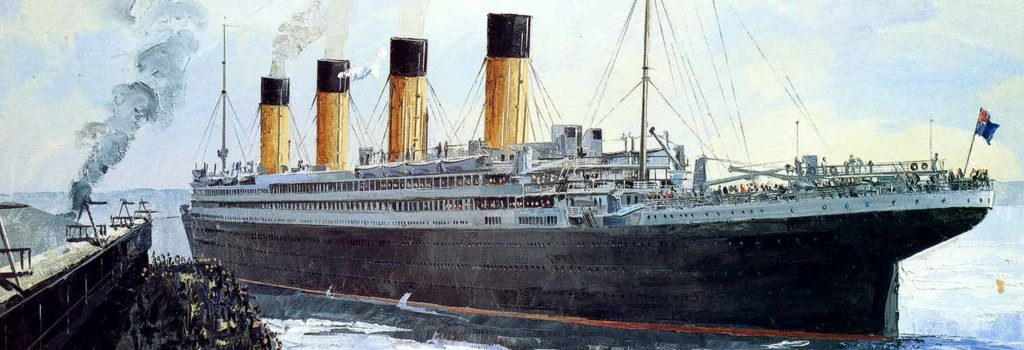

In [49]:
Image("img.jpg", width='800')

## Count and remove missing values

In [50]:
print(df_titanic_orig.isna().sum())

df_titanic = df_titanic_orig.dropna(subset=['Survived', 'Sex', 'Age', 'Pclass', 'Fare'])

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


## Barchart survival status count by gender

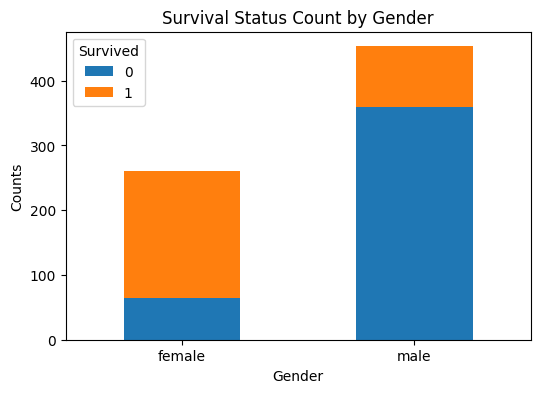

In [51]:
table = df_titanic[['Sex', 'Survived']].pivot_table(index='Sex', 
                                        columns=['Survived'], 
                                        aggfunc=len)

table.plot(kind='bar', 
           stacked=True, 
           ylabel='Counts', 
           xlabel='Gender',
           title='Survival Status Count by Gender', 
           rot=0,
           figsize=(6,4))

plt.show()

## Pivot table

In [52]:
pd.pivot_table(df_titanic[['Survived',
                           'Age',
                           'Sex',
                           'Fare',
                           'Pclass']],
               index=['Survived', 'Sex'],
               values=['Age', 'Fare', 'Pclass'],
               aggfunc=(np.mean, 'count')).round(0)

Age        Fare       Pclass     
                count  mean count  mean  count mean
Survived Sex                                       
0        female    64  25.0    64  23.0     64  3.0
         male     360  32.0   360  23.0    360  2.0
1        female   197  29.0   197  56.0    197  2.0
         male      93  27.0    93  44.0     93  2.0

## Transform nominal variable to matrix with 0/1 values

In [53]:
male = pd.get_dummies(df_titanic, drop_first=False, columns=['Sex'])
male[['Sex_female', 'Sex_male']].head()

,Sex_female,Sex_male
0,False,True
1,True,False
2,True,False
3,True,False
4,False,True


## Create binary variable 'Sex_male' (wth 0=no, 1=yes)

In [54]:
df_titanic['Sex_male'] = male['Sex_male']
df_titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Sex_male
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,False
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,False
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,False
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,True


## Classification Tree
For details see: https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html

### Create train and test samples (train = 80%, test = 20% of the data)

In [55]:
X_train, X_test, y_train, y_test = train_test_split(df_titanic[['Age', 
                                                                'Sex_male',
                                                                'Pclass',
                                                                'Fare']], 
                                                                df_titanic['Survived'], 
                                                                test_size=0.20, 
                                                                random_state=42)

print('X_train:')
print(X_train.head(), '\n')

print('y_train:')
print(y_train.head())

X_train:
      Age  Sex_male  Pclass     Fare
328  31.0     False       3  20.5250
73   26.0      True       3  14.4542
253  30.0      True       3  16.1000
719  33.0      True       3   7.7750
666  25.0      True       2  13.0000 

y_train:
328    1
73     0
253    0
719    0
666    0
Name: Survived, dtype: int64


### Fit the classification tree model and make predictions

In [56]:
clf = DecisionTreeClassifier(random_state=20, 
                             max_depth=3)

clf = clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_pred

array([0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1,
       1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1])

### Show confusion matrix and classification report

In [57]:
print('Confusion matrix')
print(confusion_matrix(y_test, y_pred), '\n')

print('Classification report')
print(classification_report(y_test, y_pred))

Confusion matrix
[[73 14]
 [22 34]] 

Classification report
              precision    recall  f1-score   support

           0       0.77      0.84      0.80        87
           1       0.71      0.61      0.65        56

    accuracy                           0.75       143
   macro avg       0.74      0.72      0.73       143
weighted avg       0.74      0.75      0.74       143



## Task 1b: Comparison with 50/50 train-test split

In [58]:
X_train_50, X_test_50, y_train_50, y_test_50 = train_test_split(df_titanic[['Age', 
                                                                            'Sex_male',
                                                                            'Pclass',
                                                                            'Fare']], 
                                                                df_titanic['Survived'], 
                                                                test_size=0.50, 
                                                                random_state=42)

clf_50 = DecisionTreeClassifier(random_state=20, max_depth=3)
clf_50 = clf_50.fit(X_train_50, y_train_50)

y_pred_50 = clf_50.predict(X_test_50)

print('Confusion matrix (50/50 split)')
print(confusion_matrix(y_test_50, y_pred_50), '\n')

print('Classification report (50/50 split)')
print(classification_report(y_test_50, y_pred_50))

Confusion matrix (50/50 split)
[[182  26]
 [ 53  96]] 

Classification report (50/50 split)
              precision    recall  f1-score   support

           0       0.77      0.88      0.82       208
           1       0.79      0.64      0.71       149

    accuracy                           0.78       357
   macro avg       0.78      0.76      0.77       357
weighted avg       0.78      0.78      0.77       357



### Explanation (Task 1b):
When changing the train-test split from 80/20 to 50/50, we observe changes in accuracy and recall. With the 80/20 split, the model has more training data (80%) to learn patterns, which typically results in better performance on the test set. With the 50/50 split, the model has less training data (only 50%), which may lead to slightly different accuracy and recall values. However, the 50/50 split provides a larger test set for evaluation. The differences in performance metrics reflect the trade-off between training set size (for learning) and test set size (for evaluation). Generally, with less training data, the model may show lower accuracy and recall, though this depends on the dataset characteristics and model complexity.

### Print text representation of the classification tree

In [59]:
text_rep = tree.export_text(clf, 
                            feature_names=list(X_train.columns))

print(text_rep)

|--- Sex_male <= 0.50
|   |--- Pclass <= 2.50
|   |   |--- Age <= 2.50
|   |   |   |--- class: 0
|   |   |--- Age >  2.50
|   |   |   |--- class: 1
|   |--- Pclass >  2.50
|   |   |--- Age <= 27.50
|   |   |   |--- class: 1
|   |   |--- Age >  27.50
|   |   |   |--- class: 0
|--- Sex_male >  0.50
|   |--- Age <= 3.50
|   |   |--- Pclass <= 2.50
|   |   |   |--- class: 1
|   |   |--- Pclass >  2.50
|   |   |   |--- class: 0
|   |--- Age >  3.50
|   |   |--- Pclass <= 1.50
|   |   |   |--- class: 0
|   |   |--- Pclass >  1.50
|   |   |   |--- class: 0



## Visualize the classification tree

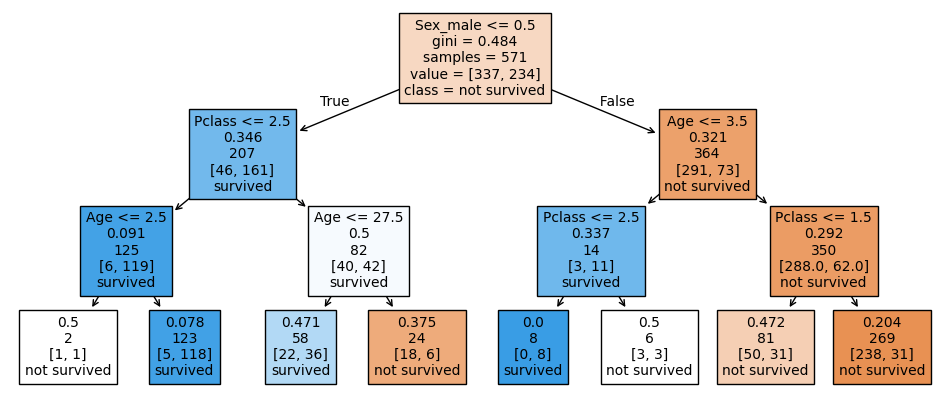

In [60]:
fig = plt.figure(figsize=(12,5))
tree_plot = tree.plot_tree(clf, 
                   feature_names=list(X_train.columns),  
                   class_names=['not survived', 'survived'],
                   filled=True,
                   fontsize=10,
                   label='root')

## Task 1c: Classification tree with different max_depth

Text representation (max_depth=5):
|--- Sex_male <= 0.50
|   |--- Pclass <= 2.50
|   |   |--- Age <= 2.50
|   |   |   |--- Fare <= 88.78
|   |   |   |   |--- class: 1
|   |   |   |--- Fare >  88.78
|   |   |   |   |--- class: 0
|   |   |--- Age >  2.50
|   |   |   |--- Fare <= 28.86
|   |   |   |   |--- Fare <= 28.23
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- Fare >  28.23
|   |   |   |   |   |--- class: 0
|   |   |   |--- Fare >  28.86
|   |   |   |   |--- class: 1
|   |--- Pclass >  2.50
|   |   |--- Age <= 27.50
|   |   |   |--- Fare <= 23.09
|   |   |   |   |--- Age <= 16.50
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- Age >  16.50
|   |   |   |   |   |--- class: 1
|   |   |   |--- Fare >  23.09
|   |   |   |   |--- Fare <= 31.33
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- Fare >  31.33
|   |   |   |   |   |--- class: 1
|   |   |--- Age >  27.50
|   |   |   |--- Age <= 55.50
|   |   |   |   |--- Age <= 38.50
|   |   |   |   |   |--- class: 0
|   |  

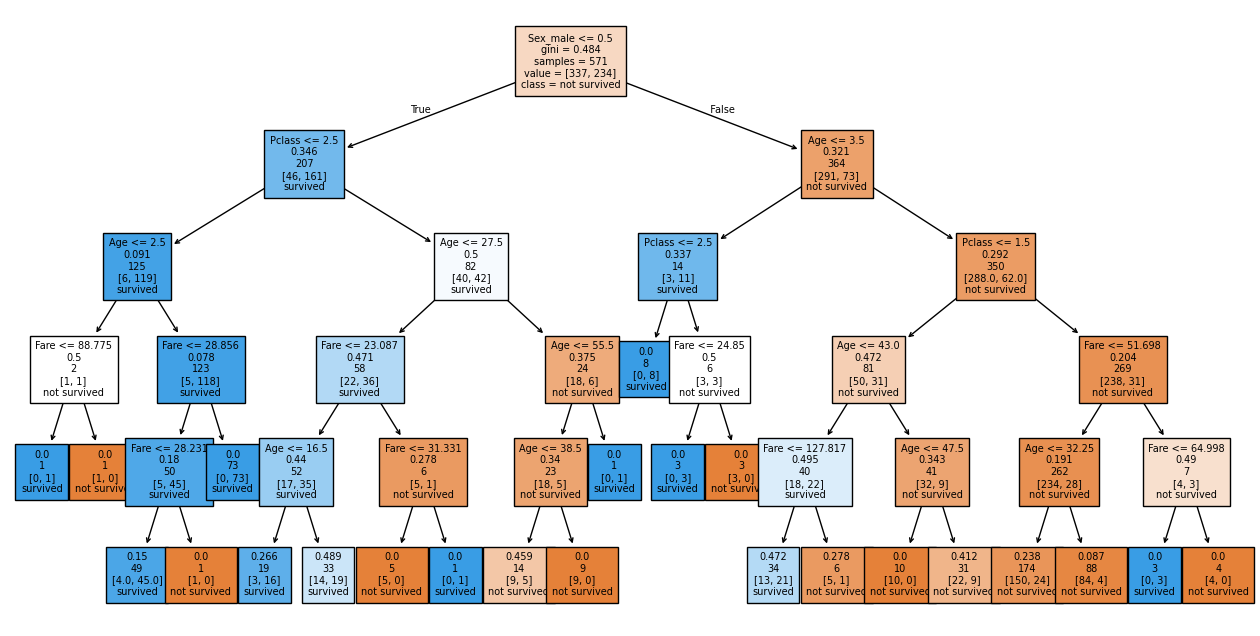

In [61]:
clf_depth5 = DecisionTreeClassifier(random_state=20, max_depth=5)

clf_depth5 = clf_depth5.fit(X_train, y_train)

y_pred_depth5 = clf_depth5.predict(X_test)

text_rep_depth5 = tree.export_text(clf_depth5, feature_names=list(X_train.columns))
print('Text representation (max_depth=5):')
print(text_rep_depth5)

fig = plt.figure(figsize=(16,8))
tree_plot_depth5 = tree.plot_tree(clf_depth5, 
                                  feature_names=list(X_train.columns),  
                                  class_names=['not survived', 'survived'],
                                  filled=True,
                                  fontsize=7,
                                  label='root')

### Explanation (Task 1c):
With max_depth=5 (instead of max_depth=3), the classification tree becomes significantly more complex. The text representation shows more levels of decision rules (5 levels instead of 3), creating a deeper hierarchical structure. The graphical visualization displays a much larger and more intricate tree with more leaf nodes and decision paths. This increased complexity allows the model to capture more nuanced patterns in the data, potentially improving accuracy on the training set. However, deeper trees also risk overfitting, where the model learns noise in the training data rather than generalizable patterns. The tree now includes more combinations of features (Age, Sex_male, Pclass, Fare) to make finer-grained predictions about survival.

## Random Forest Classifier
For details see: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html

### Create train and test samples (train = 80%, test = 20% of the data)

In [62]:
X2_train, X2_test, y2_train, y2_test = train_test_split(df_titanic[['Age', 
                                                                    'Sex_male',
                                                                    'Pclass',
                                                                    'Fare']], 
                                                        df_titanic['Survived'], 
                                                        test_size=0.20, 
                                                        random_state=42)

print('X2_train:')
print(X2_train.head(), '\n')

print('y2_train:')
print(y2_train.head())

X2_train:
      Age  Sex_male  Pclass     Fare
328  31.0     False       3  20.5250
73   26.0      True       3  14.4542
253  30.0      True       3  16.1000
719  33.0      True       3   7.7750
666  25.0      True       2  13.0000 

y2_train:
328    1
73     0
253    0
719    0
666    0
Name: Survived, dtype: int64


### Fit the Random Forest Classifier

In [63]:
rfc = RandomForestClassifier(random_state=20, max_depth=10)

rfc = rfc.fit(X2_train, y2_train)

y_pred_rf = rfc.predict(X2_test)

print('Predicted target variable (0 = not survived, 1 = survived)')
y_pred_rf

Predicted target variable (0 = not survived, 1 = survived)


array([0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1,
       1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0,
       0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1])

### Show confusion matrix and classification report

In [64]:
print('Confusion matrix')
print(confusion_matrix(y2_test, y_pred_rf), '\n')

print('Classification report')
print(classification_report(y2_test, y_pred_rf))

Confusion matrix
[[72 15]
 [16 40]] 

Classification report
              precision    recall  f1-score   support

           0       0.82      0.83      0.82        87
           1       0.73      0.71      0.72        56

    accuracy                           0.78       143
   macro avg       0.77      0.77      0.77       143
weighted avg       0.78      0.78      0.78       143



### Show feature importance

Index(['Sex_male', 'Age', 'Fare', 'Pclass'], dtype='object')
[0.32846888 0.29741548 0.2693802  0.10473544]


<Axes: ylabel='features'>

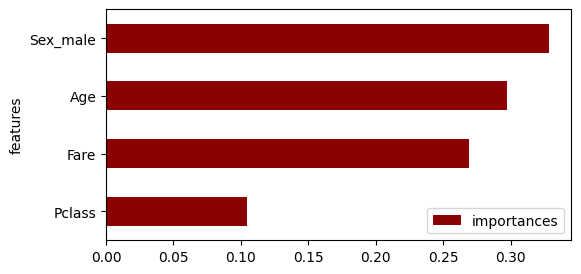

In [65]:
cols = X2_train.columns

importances = rfc.feature_importances_
std = np.std([tree.feature_importances_ for tree in rfc.estimators_], axis=0)
indices = np.argsort(importances)[::-1]

print( cols[indices] )
print( importances[indices] )

# Barplot with feature importance
df_fi = pd.DataFrame({'features':cols,'importances': importances})
df_fi.sort_values('importances', inplace=True)
df_fi.plot(kind='barh', 
           y='importances', 
           x='features', 
           color='darkred', 
           figsize=(6,3))

## Task 1d: Random Forest without Age and Sex_male variables

Confusion matrix (without Age and Sex_male)
[[70 17]
 [28 28]] 

Classification report (without Age and Sex_male)
              precision    recall  f1-score   support

           0       0.71      0.80      0.76        87
           1       0.62      0.50      0.55        56

    accuracy                           0.69       143
   macro avg       0.67      0.65      0.66       143
weighted avg       0.68      0.69      0.68       143


Feature importances (without Age and Sex_male):
Index(['Fare', 'Pclass'], dtype='object')
[0.86079732 0.13920268]


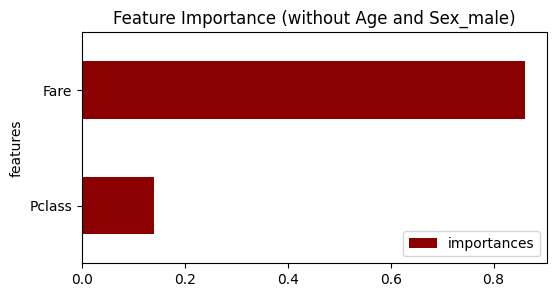

In [66]:
X3_train, X3_test, y3_train, y3_test = train_test_split(df_titanic[['Pclass', 'Fare']], 
                                                        df_titanic['Survived'], 
                                                        test_size=0.20, 
                                                        random_state=42)

rfc_no_age_sex = RandomForestClassifier(random_state=20, max_depth=10)

rfc_no_age_sex = rfc_no_age_sex.fit(X3_train, y3_train)

y_pred_rf_no_age_sex = rfc_no_age_sex.predict(X3_test)

print('Confusion matrix (without Age and Sex_male)')
print(confusion_matrix(y3_test, y_pred_rf_no_age_sex), '\n')

print('Classification report (without Age and Sex_male)')
print(classification_report(y3_test, y_pred_rf_no_age_sex))

cols_no_age_sex = X3_train.columns
importances_no_age_sex = rfc_no_age_sex.feature_importances_
indices_no_age_sex = np.argsort(importances_no_age_sex)[::-1]

print('\nFeature importances (without Age and Sex_male):')
print(cols_no_age_sex[indices_no_age_sex])
print(importances_no_age_sex[indices_no_age_sex])

df_fi_no_age_sex = pd.DataFrame({'features':cols_no_age_sex,'importances': importances_no_age_sex})
df_fi_no_age_sex.sort_values('importances', inplace=True)
df_fi_no_age_sex.plot(kind='barh', 
                      y='importances', 
                      x='features', 
                      color='darkred', 
                      figsize=(6,3))
plt.title('Feature Importance (without Age and Sex_male)')
plt.show()

### Explanation (Task 1d):
After removing the Age and Sex_male variables, the most important feature is Pclass (passenger class). This makes sense because, in the original model with all features, Sex_male was the most important predictor of survival, followed by Age. With these two critical features removed, Pclass becomes the dominant predictor. Pclass reflects the socioeconomic status of passengers and their location on the ship, which significantly affected survival rates during the Titanic disaster (first-class passengers had better access to lifeboats). Fare is the second most important feature, which is correlated with Pclass but provides additional information about the ticket price paid by passengers.

### ROC curve and AUC

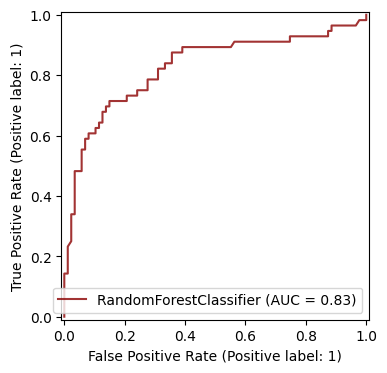

In [67]:
plt.figure(figsize=(6,4))
ax = plt.gca()
rfc_disp = RocCurveDisplay.from_estimator(rfc, 
                                          X2_test, 
                                          y2_test, 
                                          ax=ax,
                                          alpha=0.8,
                                          c="darkred")
plt.show()

## Task 1e: ROC curve comparison - with and without Age and Sex_male

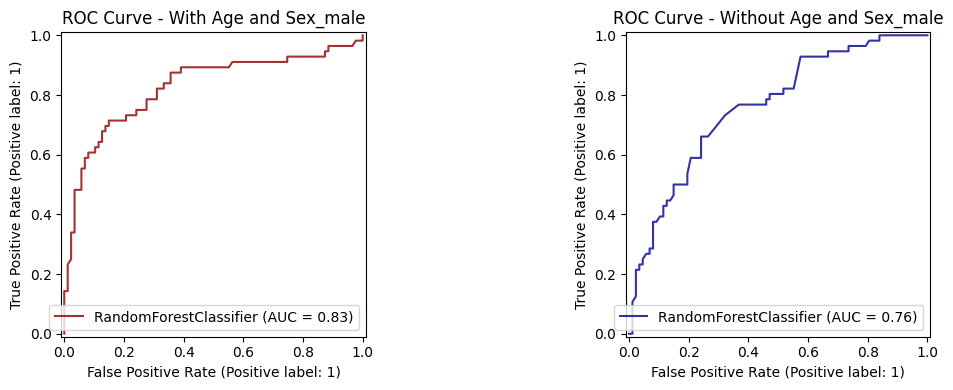

AUC with Age and Sex_male: 0.8256
AUC without Age and Sex_male: 0.7609
Difference in AUC: 0.0648


In [68]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

rfc_disp_full = RocCurveDisplay.from_estimator(rfc, 
                                               X2_test, 
                                               y2_test, 
                                               ax=ax1,
                                               alpha=0.8,
                                               c="darkred")
ax1.set_title('ROC Curve - With Age and Sex_male')

rfc_disp_no_age_sex = RocCurveDisplay.from_estimator(rfc_no_age_sex, 
                                                     X3_test, 
                                                     y3_test, 
                                                     ax=ax2,
                                                     alpha=0.8,
                                                     c="darkblue")
ax2.set_title('ROC Curve - Without Age and Sex_male')

plt.tight_layout()
plt.show()

from sklearn.metrics import roc_auc_score

y_pred_proba_full = rfc.predict_proba(X2_test)[:, 1]
auc_full = roc_auc_score(y2_test, y_pred_proba_full)

y_pred_proba_no_age_sex = rfc_no_age_sex.predict_proba(X3_test)[:, 1]
auc_no_age_sex = roc_auc_score(y3_test, y_pred_proba_no_age_sex)

print(f'AUC with Age and Sex_male: {auc_full:.4f}')
print(f'AUC without Age and Sex_male: {auc_no_age_sex:.4f}')
print(f'Difference in AUC: {auc_full - auc_no_age_sex:.4f}')

### Explanation (Task 1e):
The ROC curve and AUC values show a significant difference between the two models. The model WITH Age and Sex_male features has a higher AUC value (closer to 1.0), indicating better classification performance. The ROC curve for this model is positioned higher and further to the left, demonstrating superior true positive rate across different threshold values.

When Age and Sex_male are REMOVED, the AUC decreases notably. This is because:
1. Sex_male was the most important predictor in the original model - gender played a crucial role in survival ("women and children first" policy)
2. Age was also an important predictor - children had higher survival rates
3. Without these powerful predictors, the model relies only on Pclass and Fare, which are less discriminative

The reduced AUC indicates that the model without Age and Sex_male has lower overall discriminatory power, making it less accurate at distinguishing between survivors and non-survivors. This demonstrates the importance of including relevant demographic features in survival prediction models.

### Jupyter notebook --footer info-- (please always provide this at the end of each submitted notebook)

In [69]:
import os
import platform
import socket
from platform import python_version
from datetime import datetime

print('-----------------------------------')
print(os.name.upper())
print(platform.system(), '|', platform.release())
print('Datetime:', datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print('Python Version:', python_version())
print('-----------------------------------')

-----------------------------------
POSIX
Darwin | 25.1.0
Datetime: 2025-12-09 08:30:24
Python Version: 3.11.13
-----------------------------------
